In [1]:
import requests
import nltk
nltk.download("popular")
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import string
from nltk.corpus import stopwords
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |   

In [2]:
data = pd.read_csv("article50.csv")

In [3]:
def preprocess_text(text):
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Convert to lowercase
    text = text.lower()
    # Remove stop words
    stop_words = set(stopwords.words("english"))
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text
data["source_text"] = data["source_text"].apply(preprocess_text)
data["plagiarized_text"] = data["plagiarized_text"].apply(preprocess_text)

In [4]:
tfidf_vectorizer = TfidfVectorizer()
X = tfidf_vectorizer.fit_transform(data["source_text"] + " " + data["plagiarized_text"])
y = data["label"]

In [5]:
model = LogisticRegression()
model.fit(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_rep)

Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [6]:
joblib.dump(model, 'plagiarism_model.pkl')

['plagiarism_model.pkl']

In [7]:
# Load the saved model
loaded_model = joblib.load('plagiarism_model.pkl')

# Function to check paraphrasing using Paraphrasing and Rewriter API
def check_paraphrase(text):
    url = "https://paraphrasing-and-rewriter-api.p.rapidapi.com/rewrite-hard"
    payload = {
        "from": "en",
        "text": text
    }
    headers = {
        "x-rapidapi-key": "551c3deb3fmsh55371f1f69bb4a1p14787cjsn0c57439cf455",  # Replace with your API key
        "x-rapidapi-host": "paraphrasing-and-rewriter-api.p.rapidapi.com",
        "Content-Type": "application/json"
    }

    response = requests.post(url, json=payload, headers=headers)
    if response.status_code == 200:
        return response.json().get("rewritten_text", "")
    else:
        print("Error in paraphrasing request:", response.status_code)
        return text  # Return original text in case of failure

# New text for plagiarism detection
new_text = "New York, often called New York City or NYC, is the most populous city in the United States. With a 2020 population of 8,804,190 distributed over 300.46 square miles (778.2 km2), New York City is the most densely populated major city in the United States and more than twice as populous as Los Angeles, the nation's second-largest city."

# Preprocess the new text
new_text = preprocess_text(new_text)

# Check if the new text is paraphrased
paraphrased_text = check_paraphrase(new_text)

# Convert the preprocessed and paraphrased text into TF-IDF vectors
new_text_vector = tfidf_vectorizer.transform([paraphrased_text])

# Make predictions using the loaded model
prediction = loaded_model.predict(new_text_vector)

# Calculate cosine similarity between new text and training data
cosine_similarity_score = cosine_similarity(new_text_vector, X_train).max()

# Interpret the prediction and similarity score
if prediction[0] == 0:
    print("The text is not plagiarized.")
else:
    print(f"The text is plagiarized with a similarity score of {cosine_similarity_score*100:.2f}%.")


Error in paraphrasing request: 403
The text is not plagiarized.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13784\2644015108.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=similarity_scores, palette='viridis')


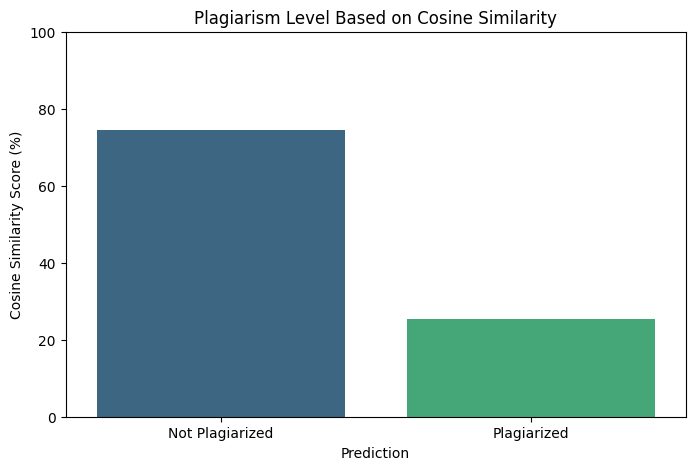

In [8]:
# Visualize plagiarism level using a bar graph
labels = ['Not Plagiarized', 'Plagiarized']
similarity_scores = [100 - cosine_similarity_score * 100, cosine_similarity_score * 100]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=similarity_scores, palette='viridis')
plt.title('Plagiarism Level Based on Cosine Similarity')
plt.xlabel('Prediction')
plt.ylabel('Cosine Similarity Score (%)')
plt.ylim(0, 100)
plt.show()